In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# One Hot Encoding

In [2]:
def OneHotEncoding(arr):
    if arr.ndim !=2:
        raise ValueError("Array must be 2 dimentional!")
    Encoder = LabelEncoder()
    arr = Encoder.fit_transform(arr)
    N_samples = arr.shape[0]
    label_unique =  np.unique(arr)
    arr_onehot = np.zeros((N_samples,label_unique.shape[0]))
    arr_onehot[range(N_samples),arr] = 1
    return arr_onehot

In [3]:
a = np.array([1,3,4,7,3,7]).reshape(-1,1)
a

array([[1],
       [3],
       [4],
       [7],
       [3],
       [7]])

In [4]:
a_onehot = OneHotEncoding(a)
a_onehot

C:\Anaconda\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.]])

# Vectorization for SoftMax Regression

In [5]:
Encoder = OneHotEncoder(sparse_output=False)
class SoftMax_Regression:
    def __init__(self, lr = 0.01, shuffle = False, w = None, random_state = 42, verbose = 1, activate_function = 'SoftMax'):
        self.lr = lr # learning rate - speed of learning of model
        self.n_epochs = None # the number learning of model
        self.batch_size = None # the number sample is selected to training to update weight of model
        self.shuffle = shuffle # the param decide do you want swap all sample of training set before each epoch
        self.w = w # the weight of model
        self.verbose = verbose
        self.N_samples = None # the number of sample of training set
        self.N_features = None # the number of feature of training set
        if activate_function == 'SoftMax':
            self.activate_function = self.SoftMax
        self.validation_split = None # % of validation set
        self.N_categoris = None # the number of class
        self.train_Losses = []
        self.train_Accuracies = []
        self.val_Losses = []
        self.val_Accuracies = []
        self.random_state = random_state
        np.random.seed(self.random_state)
    # function to check the dimension of array
    def CheckDim(self, X):
        if X.ndim == 1:
            raise ValueError(f" X must be 2 dimension!")
        return 1

    # function to add the feature 1 on head of each sample
    def Addfeature1(self, X):
        if self.CheckDim(X):
            if X.shape[1] == self.N_features +1: return X
            feature1 = np.ones((X.shape[0],1))
            return np.concatenate((feature1,X), axis = 1)

    
    # active function - SoftMax
    def SoftMax(self,z):
        m = np.max(z,axis=1,keepdims = True)
        exp_z = np.exp(z-m)
        return exp_z/np.sum(exp_z,axis = 1, keepdims=True)

    # foward - function to predict probability
    def predict_proba(self, X):
        X = self.Addfeature1(X)
        z = np.dot(X,self.w)
        return self.activate_function(z)

    # function to predict the label of sample
    def predict(self,X):
        return np.argmax(self.predict_proba(X),axis=1)

    # function to compute Loss
    def Compute_loss(self, y_pred, y):
        y_pred = np.clip(y_pred,1e-15,1 - 1e-15)
        return np.mean(np.sum(-y*np.log(y_pred),axis=1))

    # function to compute derivative dL/dw
    def dL_dw(self, X, y_pred, y):
        return X.T@(y_pred-y)*(1/X.shape[0])

    # function to train model 
    def fit(self,X, y, n_epochs = 100, batch_size = 1, validation_split = 0.15):
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.validation_split = validation_split
        
        # check dimentional of X_train_input
        if self.CheckDim(X):
            self.N_features = X.shape[1]
        # add feature 1 on head of each sample
        X = self.Addfeature1(X)
        # check dimentional of y
        if self.CheckDim(y):
            # tranfer y become onehost encoding
            Encoder.fit(y)
            Y = Encoder.transform(y)
            self.N_categories = Y.shape[1]
        if self.w is None:
            self.w = np.random.uniform(-1,1, size=(self.N_features+1, self.N_categories))
        X_train_set, X_val_set, Y_train_set, Y_val_set = train_test_split(X, Y, test_size=validation_split,random_state=self.random_state)
        self.N_samples = X_train_set.shape[0]
        data_train = np.concatenate((X_train_set,Y_train_set),axis = 1)
        # the batch's number of each epoch
        num_batch = self.N_samples// self.batch_size if self.N_samples % self.batch_size == 0 else (self.N_samples// self.batch_size)+1
        for epoch in range(self.n_epochs):
            count_batch = 1
            train_loss_epoch = []
            train_accuracy_epoch = []
            if self.shuffle: np.random.shuffle(data_train)
            if self.verbose != 0:
                print(f"Epoch {epoch+1}/{self.n_epochs}")
            for i in range(0, self.N_samples, self.batch_size):
                X_train, Y_train  = data_train[i:i+self.batch_size, :-self.N_categories], data_train[i:i+self.batch_size,-self.N_categories:]
                Y_pred = self.predict_proba(X_train)
                y_pred = self.predict(X_train)
                Loss = self.Compute_loss(Y_pred,Y_train)
                Accuracy = np.mean(y_pred == np.argmax(Y_train,axis=1))
                train_loss_epoch.append(Loss)
                train_accuracy_epoch.append(Accuracy)
                # compute derivative dL/dw
                dL_dw = self.dL_dw(X_train, Y_pred, Y_train)
                # update weight of model
                self.w -= self.lr*dL_dw
                if self.verbose == 1:
                    if count_batch != num_batch:
                        print(f"{count_batch}/{num_batch} [=====================] - Loss = {Loss:.2f} - Accuracy = {Accuracy:.2f}")
                count_batch+=1
            Y_pred_val = self.predict_proba(X_val_set)
            y_pred_val = self.predict(X_val_set)
            Loss_val = self.Compute_loss(Y_pred_val, Y_val_set)
            Accuracy_val = np.mean(y_pred_val == np.argmax(Y_val_set, axis = 1))
            self.val_Losses.append(Loss_val)
            self.val_Accuracies.append(Accuracy_val)
            self.train_Losses.append(sum(train_loss_epoch)/len(train_loss_epoch))
            self.train_Accuracies.append(sum(train_accuracy_epoch)/len(train_accuracy_epoch))
            if self.verbose == 1:
                print(f"{count_batch}/{num_batch} [=====================] - Loss = {Loss:.2f} - Accuracy = {Accuracy:.2f} - Loss_val = {Loss_val:.2f} - Accuracy_val = {Accuracy_val:.2f}")
            if self.verbose == 2:
                print(f"Loss = {self.train_Losses[-1]} - Accuracy = {self.train_Accuracies[-1].item():.2f} - Loss_val = {self.val_Losses[-1].item():.2f} - Accuracy_val = {self.val_Accuracies[-1].item():.2f}")

In [6]:
FILE_PATH = 'data/Iris.csv'

In [7]:
df = pd.read_csv(FILE_PATH,index_col='Id')
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
X = df.iloc[:,:-1]
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Id,,,,
1,5.1,3.5,1.4,0.2
2,4.9,3.0,1.4,0.2
3,4.7,3.2,1.3,0.2
4,4.6,3.1,1.5,0.2
5,5.0,3.6,1.4,0.2
...,...,...,...,...
146,6.7,3.0,5.2,2.3
147,6.3,2.5,5.0,1.9
148,6.5,3.0,5.2,2.0


In [9]:
y = df.iloc[:,-1]
y

Id
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
5         Iris-setosa
            ...      
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
150    Iris-virginica
Name: Species, Length: 150, dtype: object

In [10]:
X = X.to_numpy()

In [11]:
Encoder_label = LabelEncoder()
y = Encoder_label.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [12]:
y = y.reshape(-1,1)
y

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
    

In [13]:
N_samples = X.shape[0]
print(N_samples)
N_features = X.shape[1]
print(N_features)

150
4


In [14]:
# split train set and test set
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.15,random_state=42,shuffle=True)

In [15]:
# Khởi tạo mô hình và huấn luyện
clf = SoftMax_Regression(shuffle=True,verbose=2)

In [25]:
clf.fit(X_train,y_train,validation_split=0.19,batch_size=16,n_epochs=80)

Epoch 1/80
Loss = 0.2981050560463766 - Accuracy = 0.96 - Loss_val = 0.26 - Accuracy_val = 0.96
Epoch 2/80
Loss = 0.28953559289956793 - Accuracy = 0.96 - Loss_val = 0.26 - Accuracy_val = 0.96
Epoch 3/80
Loss = 0.28847321797544584 - Accuracy = 0.97 - Loss_val = 0.26 - Accuracy_val = 0.96
Epoch 4/80
Loss = 0.2906587229790238 - Accuracy = 0.94 - Loss_val = 0.26 - Accuracy_val = 0.96
Epoch 5/80
Loss = 0.28589221549167493 - Accuracy = 0.96 - Loss_val = 0.26 - Accuracy_val = 0.96
Epoch 6/80
Loss = 0.2888912277361789 - Accuracy = 0.96 - Loss_val = 0.26 - Accuracy_val = 0.96
Epoch 7/80
Loss = 0.28703918553981284 - Accuracy = 0.95 - Loss_val = 0.26 - Accuracy_val = 0.96
Epoch 8/80
Loss = 0.29124995535437403 - Accuracy = 0.97 - Loss_val = 0.26 - Accuracy_val = 0.96
Epoch 9/80
Loss = 0.284057190253635 - Accuracy = 0.96 - Loss_val = 0.26 - Accuracy_val = 0.96
Epoch 10/80
Loss = 0.2994785923390685 - Accuracy = 0.95 - Loss_val = 0.26 - Accuracy_val = 0.96
Epoch 11/80
Loss = 0.28279759119031966 - Accu

Text(0, 0.5, 'Loss')

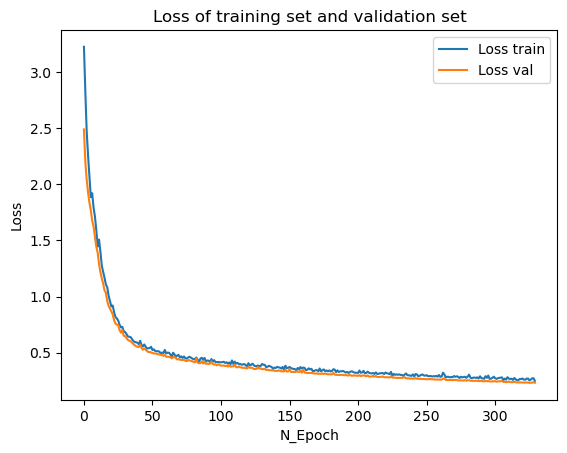

In [26]:
plt.title("Loss of training set and validation set")
plt.plot(clf.train_Losses,label = 'Loss train')
plt.plot(clf.val_Losses, label = 'Loss val')
plt.legend()
plt.xlabel("N_Epoch")
plt.ylabel("Loss")

Text(0, 0.5, 'Accuracy')

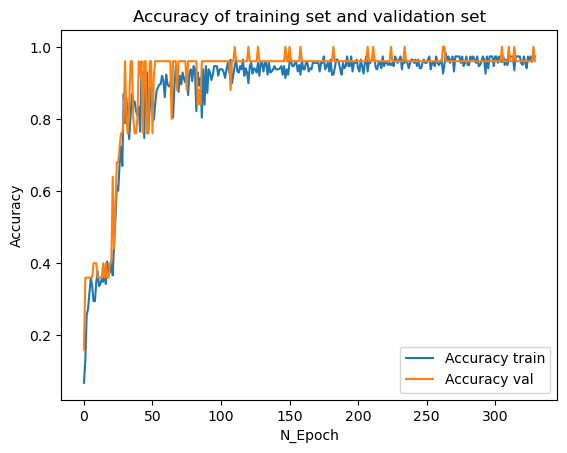

In [27]:
plt.title("Accuracy of training set and validation set")
plt.plot(clf.train_Accuracies,label = 'Accuracy train')
plt.plot(clf.val_Accuracies, label = 'Accuracy val')
plt.legend()
plt.xlabel("N_Epoch")
plt.ylabel("Accuracy")

In [30]:
y_pred_test = clf.predict(X_test)
y_pred_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0])

In [31]:
print(f"Độ chính xác của mô hình: {accuracy_score(y_pred_test,y_test):.2f}")

Độ chính xác của mô hình: 1.00
